<font size=6>实验5：计算机视觉</font>

# 实验简介

本实验以目标检测（Object Detection）任务为例，介绍如何利用深度学习技术搭建计算机视觉系统。

在实验中，我们将直接加载YOLOv8预训练模型，以完成目标检测任务，并观察模型输出形式及模型效果。通过本实验，你将掌握以下技能：

- 了解YOLO系列目标检测算法的基本原理；
- 了解`ultralytics`包的使用方法；
- 利用预训练模型，构建一个简单的目标检测系统。

# YOLO目标检测算法介绍

YOLO（You Only Look Once）是一种经典单阶段目标检测算法。该模型具有实时性高、鲁棒性好、兼顾准确性与速度等优点，在工业界得到了广泛应用。

YOLOv1、v2、v3是最初提出YOLO算法的团队的作品，团队的主要成员是来自华盛顿大学的Joseph Redmon。从YOLOv4开始，后续的一系列升级版本是由世界各地不同团队开发的，与原始YOLO算法的团队已经没有直接关系。

YOLOv8是2023年Ultralytics公司提出的目标检测算法，该算法在既有模型基础上进一步改进，相较于YOLOv1~v3，使用了新的主干网络，引入了无锚框思想，增强了模型结构的多样性、灵活性。

在本实验中，我们将尝试使用YOLOv8模型进行目标检测。YOLOv8系列包含5个模型（YOLOv8n、YOLOv8s、YOLOv8m、YOLOv8l、YOLOv8x），其中YOLOv8 Nano（YOLOv8n）是最小的模型，速度最快；YOLOv8 Extra Large (YOLOv8x) 则是参数规模最大、最准确的模型，但速度最慢。

# 实验环境准备

首先，你需要安装完成本实验所需的必要组件。

## 安装Miniconda

从以下链接下载Miniconda安装包并完成安装[[Link]](https://mirrors.tuna.tsinghua.edu.cn/anaconda/miniconda/Miniconda3-py310_24.1.2-0-Windows-x86_64.exe)，安装过程中需要选中`Register Anaconda as my default Python 3.10`。若计算机上已经安装好Miniconda或Anaconda，请跳过此步骤。

## 安装必要的Package

在`Anaconda Prompt`中，通过`pip`包管理器安装`Jupyter Notebook`、`pillow`、`opencv-python`、`matplotlib`、`PyTorch`及`ultralytics`包。

```bash
pip install notebook -i https://pypi.tuna.tsinghua.edu.cn/simple/
pip install pillow -i https://pypi.tuna.tsinghua.edu.cn/simple/
pip install opencv-python -i https://pypi.tuna.tsinghua.edu.cn/simple/
pip install matplotlib -i https://pypi.tuna.tsinghua.edu.cn/simple/
pip install torch -i https://pypi.tuna.tsinghua.edu.cn/simple/
pip install ultralytics -i https://pypi.tuna.tsinghua.edu.cn/simple/
```

当然，可以直接通过以下命令进行全局修改，而不必每次都指定`-i`参数：

```bash
pip config set global.index-url https://pypi.tuna.tsinghua.edu.cn/simple
```

你可以通过执行以下Python代码，检查上述包是否已经安装完成。

In [1]:
from importlib.util import find_spec

# 检查pillow是否已安装
if find_spec('PIL').loader:
    print('pillow is available.')

# 检查opencv-python是否已安装
if find_spec('cv2').loader:
    print('opencv-python is available.')

# 检查matplotlib是否已安装
if find_spec('matplotlib').loader:
    print('matplotlib is available.')

# 检查PyTorch是否已安装
if find_spec('torch').loader:
    print('PyTorch is available.')

# 检查ultralytics是否已安装
if find_spec('ultralytics').loader:
    print('ultralytics is available.')

pillow is available.
opencv-python is available.
matplotlib is available.
PyTorch is available.
ultralytics is available.


本实验使用的Ultralytics包为YOLOv8提供了完整的命令行界面 (CLI) API和Python SDK，用于方便地执行模型的训练、验证和推理。该项目的地址为：

https://github.com/ultralytics/ultralytics

# 在命令行中调用模型

在安装`ultralytics`包之后，可以直接在命令行调用`yolo`工具，进行YOLO模型的训练和推理（预测）。例如，在命令行输入以下命令，进行模型预测实验：

```bash
yolo predict model=yolov8n.pt imgsz=640 conf=0.25
```

执行后，命令行工具将自动下载模型预训练权重文件`yolov8n.pt`，并执行预测（推理）任务，由于这里没有指定自己的文件路径，该工具将会对两张测试图片进行预测，并将预测结果存放于当前工作目录的`runs/detect/predict`子目录下。

> **注意：如果模型权重文件下载速度较慢，可直接下载课堂上分发的文件，并将`yolov8n.pt`文件放置在命令行的当前工作目录下。**

点击以下链接可查看命令行工具支持的配置项：[[Link]](https://docs.ultralytics.com/usage/cfg/)。

# 在Python脚本中调用模型

更常用的方式是直接在Python脚本中导入`ultralytics`包，以便进行YOLO模型的训练、推理。例如，你可以打开一个Jupyter Notebook，并执行以下代码，执行目标检测任务。

同样地，`YOLO`模块将会检查当前工作目录下是否存在你指定的模型权重文件（如`yolov8n.pt`），如果文件不存在，则会下载权重文件到当前工作目录。

In [2]:
# 防止可能的kmp_duplicate_lib_ok错误
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [3]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
results = model.predict('https://ultralytics.com/images/bus.jpg', save=True)


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 D:\Code\nndl\ex5\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 53.7ms
Speed: 2.7ms preprocess, 53.7ms inference, 10.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to D:\Code\nndl\ex5\runs\detect\predict-2


如果你希望检查当前工作目录是什么，只需执行以下代码段。如果使用的是Jupyter Notebook环境，当前工作目录就是创建Notebook的目录。当然，你可以利用`os.chdir()`改变当前工作目录。

In [ ]:
import os
print(os.getcwd())

# 将YOLO目标检测器整合到项目中

在真实生产环境下的计算机视觉项目中，我们通常希望将YOLO目标检测器直接作为一个模块完成目标检测任务，并将结果放置在内存对象中（而不是将结果输出到文件）。这里给出了相关代码示例。

首先，导入所需的包。

In [5]:
from ultralytics import YOLO
import numpy as np
from PIL import Image
import requests
from io import BytesIO
from matplotlib import pyplot as plt
import cv2
import os

os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

定义辅助函数，实现目标边界框的绘制。

In [6]:
def box_label(image, box, label='', color=(128, 128, 128), txt_color=(255, 255, 255)):
    lw = max(round(sum(image.shape) / 2 * 0.003), 2)
    p1, p2 = (int(box[0]), int(box[1])), (int(box[2]), int(box[3]))
    cv2.rectangle(image, p1, p2, color, thickness=lw, lineType=cv2.LINE_AA)
    if label:
        tf = max(lw - 1, 1)  # font thickness
        w, h = cv2.getTextSize(label, 0, fontScale=lw / 3, thickness=tf)[0]  # text width, height
        outside = p1[1] - h >= 3
        p2 = p1[0] + w, p1[1] - h - 3 if outside else p1[1] + h + 3
        cv2.rectangle(image, p1, p2, color, -1, cv2.LINE_AA)  # filled
        cv2.putText(image,
                    label, (p1[0], p1[1] - 2 if outside else p1[1] + h + 2),
                    0,
                    lw / 3,
                    txt_color,
                    thickness=tf,
                    lineType=cv2.LINE_AA)

def plot_bboxes(image, boxes, labels=[], colors=[], score=True, conf=None):
    if labels == []:
        labels = {0: u'__background__', 1: u'person', 2: u'bicycle',3: u'car', 4: u'motorcycle', 5: u'airplane', 6: u'bus', 7: u'train', 8: u'truck', 9: u'boat', 10: u'traffic light', 11: u'fire hydrant', 12: u'stop sign', 13: u'parking meter', 14: u'bench', 15: u'bird', 16: u'cat', 17: u'dog', 18: u'horse', 19: u'sheep', 20: u'cow', 21: u'elephant', 22: u'bear', 23: u'zebra', 24: u'giraffe', 25: u'backpack', 26: u'umbrella', 27: u'handbag', 28: u'tie', 29: u'suitcase', 30: u'frisbee', 31: u'skis', 32: u'snowboard', 33: u'sports ball', 34: u'kite', 35: u'baseball bat', 36: u'baseball glove', 37: u'skateboard', 38: u'surfboard', 39: u'tennis racket', 40: u'bottle', 41: u'wine glass', 42: u'cup', 43: u'fork', 44: u'knife', 45: u'spoon', 46: u'bowl', 47: u'banana', 48: u'apple', 49: u'sandwich', 50: u'orange', 51: u'broccoli', 52: u'carrot', 53: u'hot dog', 54: u'pizza', 55: u'donut', 56: u'cake', 57: u'chair', 58: u'couch', 59: u'potted plant', 60: u'bed', 61: u'dining table', 62: u'toilet', 63: u'tv', 64: u'laptop', 65: u'mouse', 66: u'remote', 67: u'keyboard', 68: u'cell phone', 69: u'microwave', 70: u'oven', 71: u'toaster', 72: u'sink', 73: u'refrigerator', 74: u'book', 75: u'clock', 76: u'vase', 77: u'scissors', 78: u'teddy bear', 79: u'hair drier', 80: u'toothbrush'}
    if colors == []:
        colors = [(89, 161, 197),(67, 161, 255),(19, 222, 24),(186, 55, 2),(167, 146, 11),(190, 76, 98),(130, 172, 179),(115, 209, 128),(204, 79, 135),(136, 126, 185),(209, 213, 45),(44, 52, 10),(101, 158, 121),(179, 124, 12),(25, 33, 189),(45, 115, 11),(73, 197, 184),(62, 225, 221),(32, 46, 52),(20, 165, 16),(54, 15, 57),(12, 150, 9),(10, 46, 99),(94, 89, 46),(48, 37, 106),(42, 10, 96),(7, 164, 128),(98, 213, 120),(40, 5, 219),(54, 25, 150),(251, 74, 172),(0, 236, 196),(21, 104, 190),(226, 74, 232),(120, 67, 25),(191, 106, 197),(8, 15, 134),(21, 2, 1),(142, 63, 109),(133, 148, 146),(187, 77, 253),(155, 22, 122),(218, 130, 77),(164, 102, 79),(43, 152, 125),(185, 124, 151),(95, 159, 238),(128, 89, 85),(228, 6, 60),(6, 41, 210),(11, 1, 133),(30, 96, 58),(230, 136, 109),(126, 45, 174),(164, 63, 165),(32, 111, 29),(232, 40, 70),(55, 31, 198),(148, 211, 129),(10, 186, 211),(181, 201, 94),(55, 35, 92),(129, 140, 233),(70, 250, 116),(61, 209, 152),(216, 21, 138),(100, 0, 176),(3, 42, 70),(151, 13, 44),(216, 102, 88),(125, 216, 93),(171, 236, 47),(253, 127, 103),(205, 137, 244),(193, 137, 224),(36, 152, 214),(17, 50, 238),(154, 165, 67),(114, 129, 60),(119, 24, 48),(73, 8, 110)]

    for box in boxes:
        if score :
            label = labels[int(box[-1])+1] + " " + str(round(100 * float(box[-2]),1)) + "%"
        else :
            label = labels[int(box[-1])+1]
        #filter every box under conf threshold if conf threshold setted
        if conf :
            if box[-2] > conf:
                color = colors[int(box[-1])]
                box_label(image, box, label, color)
        else:
            color = colors[int(box[-1])]
            box_label(image, box, label, color)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.imshow(image)

接下来，定义一个`obj_predict`函数，其输入是互联网图片的URL，该函数将根据URL获取图片并利用YOLOv8模型进行目标检测，最终将检测结果显示出来。

In [7]:
def obj_predict(image_url, model="yolov8n.pt"):
    model = YOLO(model)
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content))
    image = np.asarray(image)
    result = model.predict(image)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plot_bboxes(image, result[0].boxes.data, score=False)

函数功能测试：


0: 448x640 3 zebras, 2 giraffes, 30.8ms
Speed: 12.5ms preprocess, 30.8ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)


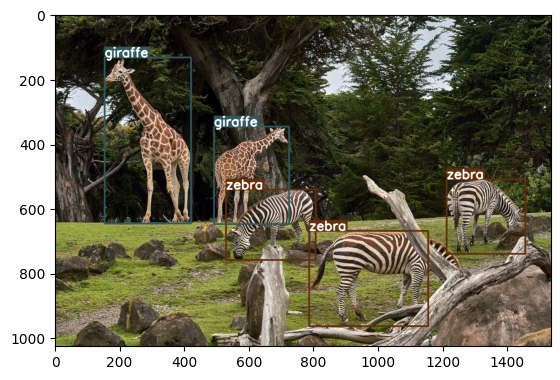

In [8]:
obj_predict("https://radioemaus.pl/app/uploads/2020/11/nikolay-tchaouchev-ttpNCevA1tA-unsplash-1536x1025.jpg")

> **接下来，尝试将测试图片替换为其他网络图片，观察模型的效果。**